<a href="https://colab.research.google.com/github/diego-ascenciorod/Clase-Laboratorio-Estadistico/blob/main/T08_Optimizaci%C3%B3n_Bayesiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimización Bayesiana

**Teorema de Bayes**

$$ P(A|B) = \frac{P(B|A) P(A)}{P(B)} $$

$ P(A|B) $: Probabilidad condicional de A dado B. También conocida como la probabilidad posterior de A dado que B ocurre.

$ P(B|A) $: Probabilidad condicional de B dado A. Se interpreta como la verosimilitud (*likelihood*) de A.

$ P(A) $: Probabilidad de observar A. También conocida como probabilidad a priori.

$ P(B) $: Probabilidad de observar B. Interpretada como evidencia.

Utilizando las definiciones de arriba actualizamos la definición del teorema de bayes:

$$ \text{posterior} = \frac{(\text{verosimilitud})(\text{anterior})}{\text{evidencia}} $$

La intuición es que el teorema de Bayes es una herramienta para actualizar nuestras creencias dado lo que se tenía antes y nueva evidencia. Por ejemplo, tomas una moneda y asumes que es una moneda justa, dado que es lo más probable y que las monedas suelen ser justas en tu experiencia. Lanzas la moneda tres veces y cae sello las tres veces; un poco extraño, así que ajustas tus creencias y empiezas a imaginar que la moneda no es tan justa como debería ser. Lanzas las monedas tres veces y cae águila; ahora crees que la moneda es justa de nuevo.

## ¿Cómo aplicamos esto en nuestra vida diaria?

Imagina que tienes 3 puntos (conocimiento previo) en un espacio.

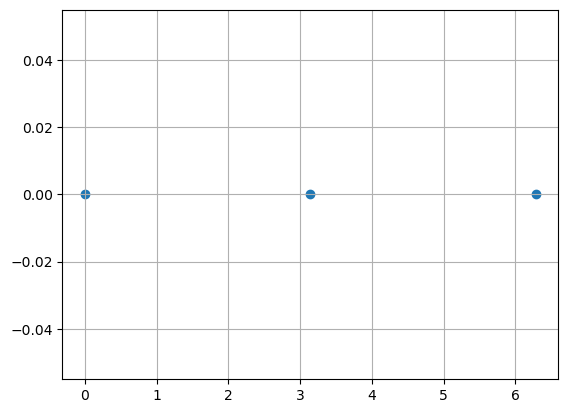

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(); plt.scatter([0, np.pi, 2*np.pi], [0, 0, 0]); plt.grid()

No hay seguridad de cómo se conectan estos puntos, pero sabes que están conectados. Hay infinitas formas en las que estos puntos se pueden conectar.

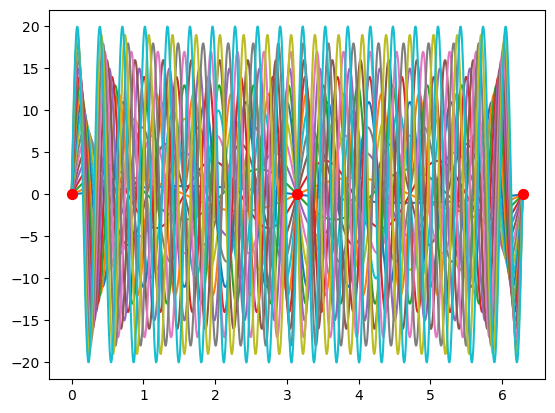

In [ ]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure();
for i in range(20) :
    y = (i+1)*np.sin((i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi], [0, 0, 0], s=50, c="r", zorder=3)

Hay tanta incertidumbre que decides pedir más información y te dan otro punto.

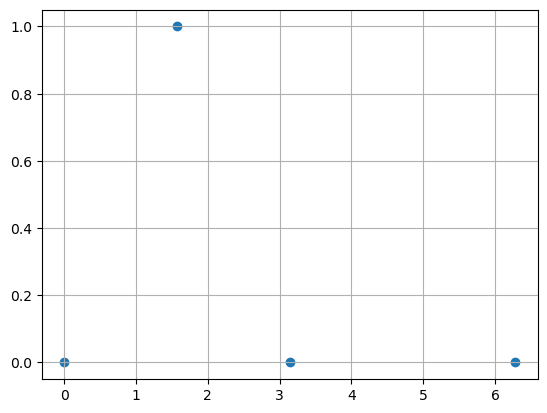

In [ ]:
plt.figure(); plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1]); plt.grid()

Con esta nueva información actualizas tus creencias y reduces la cantidad de formas en las que se conectan estos puntos (siguen siendo infinitas).

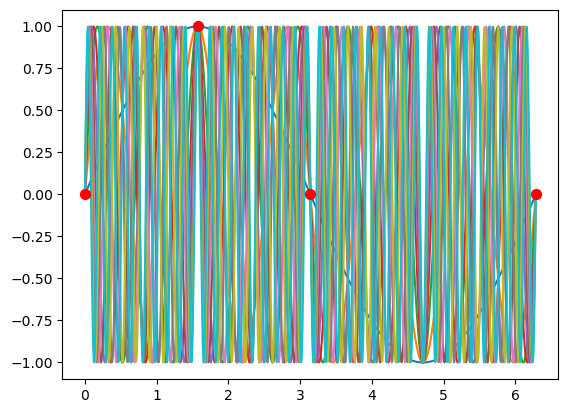

In [ ]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure();
for i in range(10) :
    y = np.sin((4*i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1], s=50, c="r", zorder=3)

Te pones a pensar: "Sí. Teóricamente hay infinitas funciones que pueden conectar estos puntos, pero sólo algunas tienen sentido dado mi contexto."

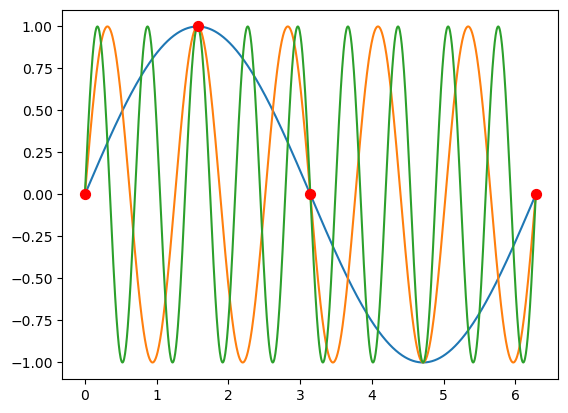

In [ ]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure();
for i in range(3) :
    y = np.sin((4*i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1], s=50, c="r", zorder=3)

Ahora sólo quedan algunos pocos candidatos dado el criterio que tienes. Hay incertidumbre sobre cuál de estos candidatos podría ser el que mejor se ajusta, así que decides pedir más información. ¿Qué información serviría más?
- Se podría pedir el valor de $y$ cuando $x=\frac{3\pi}{2}$, pero los candidatos que tenemos todos pasan por el mismo punto. Incluso si nos dieran la información, no ayudaría de mucho.
- Se podría pedir fuera del rango que tenemos, pero quizás la información no existe o dado el contexto del problema es imposible que estos puntos existan.

Nos asignan nuestro último punto.

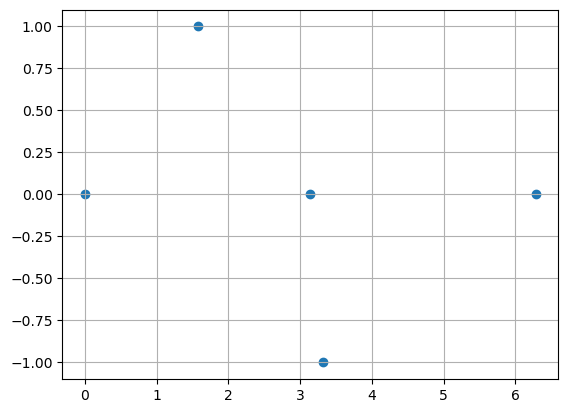

In [ ]:
plt.figure(); plt.scatter([0, np.pi, 2*np.pi, np.pi/2, 19*np.pi/18], [0, 0, 0, 1, -1]); plt.grid()

Usamos esta nueva información (evidencia) junto con lo que conocíamos (anterior) y lo que creemos que es posible (verosimilitud) para decidir sobre una nueva función (posterior).

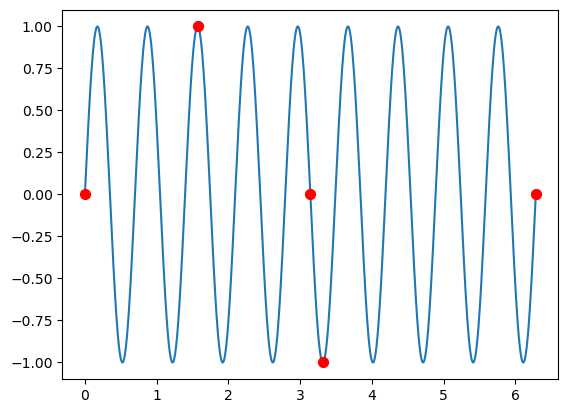

In [ ]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); y = np.sin(9*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2, 19*np.pi/18], [0, 0, 0, 1, -1], s=50, c="r", zorder=3)

Una forma de realizar este experimento es mediante un proceso gaussiano, que asume que la variable de salida es una variable aleatoria con distribución normal multivariada. Utilicemos la función que encontramos y asumamos que no sabemos cuál es.

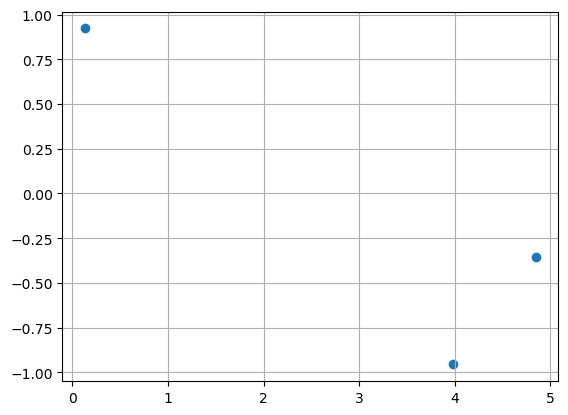

In [ ]:
np.random.seed(10)
def f(x) :
    return np.sin(9*x)
X = np.random.uniform(0, 2*np.pi, 3).reshape([-1, 1])
plt.figure(); plt.scatter(X, f(X)); plt.grid()

Realizamos una regresión de proceso gaussiano para encontrar distribuciones que podrían darnos estas muestras

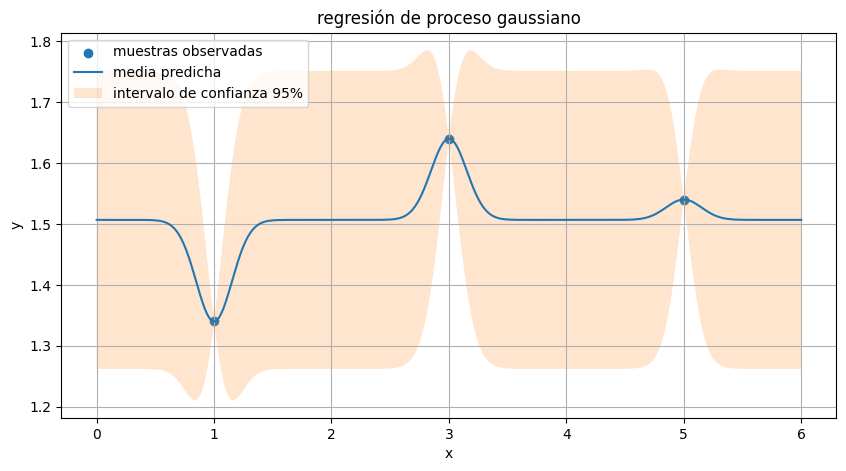

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# muestras
X_train = np.array([[1.0], [3.0], [5.0]])
y_train = np.array([1.34, 1.64, 1.54])

# puntos donde quiero predecir
X = np.linspace(0, 6, 300).reshape(-1, 1)

# kernel
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

# modelo
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=10)

# ajuste
gp.fit(X_train, y_train)

# predicción
y_mean, y_std = gp.predict(X, return_std=True)

# gráfica
plt.figure(figsize=(10,5))
plt.scatter(X_train, y_train, label="muestras observadas")
plt.plot(X, y_mean, label="media predicha")
plt.fill_between(
    X.ravel(),
    y_mean - 1.96*y_std,
    y_mean + 1.96*y_std,
    alpha=0.2,
    label="intervalo de confianza 95%"
)

plt.title("regresión de proceso gaussiano")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

Creamos un vector de valores posibles de $x$ y predecimos $y$ usando el resultado de la regresión.

In [3]:
# vector de valores posibles de x
X_test = np.linspace(0, 6, 100).reshape(-1, 1)

# predicción usando el modelo
y_pred, y_std = gp.predict(X_test, return_std=True)

# ver algunos resultados
for i in range(5):
    print(f"x = {X_test[i][0]:.2f}, y = {y_pred[i]:.4f}, std = {y_std[i]:.4f}")

x = 0.00, y = 1.5067, std = 0.1247
x = 0.06, y = 1.5067, std = 0.1247
x = 0.12, y = 1.5067, std = 0.1247
x = 0.18, y = 1.5067, std = 0.1247
x = 0.24, y = 1.5067, std = 0.1247


Graficamos nuestra primera propuesta, utilizando el error estándar para dibujar nuestros intervalos de confianza.

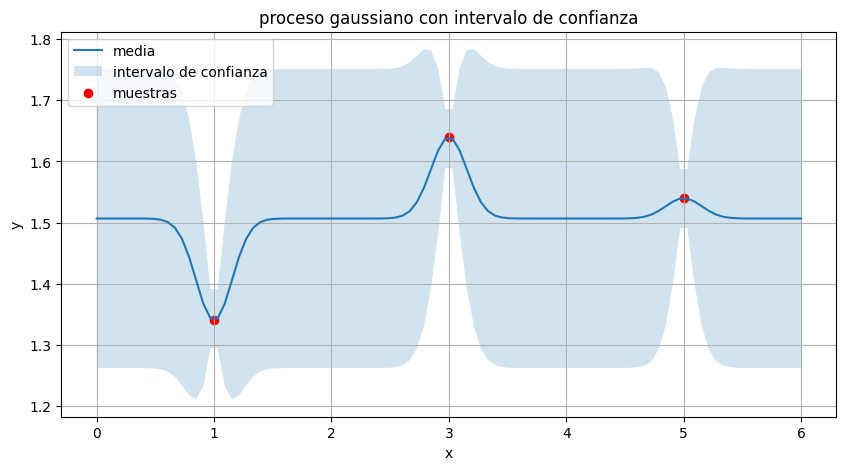

In [4]:
plt.figure(figsize=(10,5))

# media
plt.plot(X_test, y_pred, label="media")

# intervalo de confianza (95%)
plt.fill_between(
    X_test.ravel(),
    y_pred - 1.96*y_std,
    y_pred + 1.96*y_std,
    alpha=0.2,
    label="intervalo de confianza"
)

# puntos originales
plt.scatter(X_train, y_train, color="red", label="muestras")

plt.title("proceso gaussiano con intervalo de confianza")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()

Podemos ver que necesitamos más muestras debido a que hay mucha incertidumbre en algunas partes de nuestro dominio. Hay varios criterios para decidir cómo pedir muestras:
- Maximizar (busco mi predicción del máximo actual y pido esa medida)
- Minimizar (busco mi predicción del mínimo actual y pido esa medida)
- Reducir incertidumbre (busco el punto donde mi intervalo de confianza es más grande y pido esa medida)

In [5]:
#maximizar
x_max = X_test[np.argmax(y_pred)]

#minimizar
x_min = X_test[np.argmin(y_pred)]

#reducir incertidumbre (donde std es mayor)
x_uncertainty = X_test[np.argmax(y_std)]

print("punto para maximizar:", x_max[0])
print("punto para minimizar:", x_min[0])
print("punto con mayor incertidumbre:", x_uncertainty[0])

punto para maximizar: 2.9696969696969697
punto para minimizar: 0.9696969696969697
punto con mayor incertidumbre: 0.0


Y repetimos el proceso ya con nueva información.

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


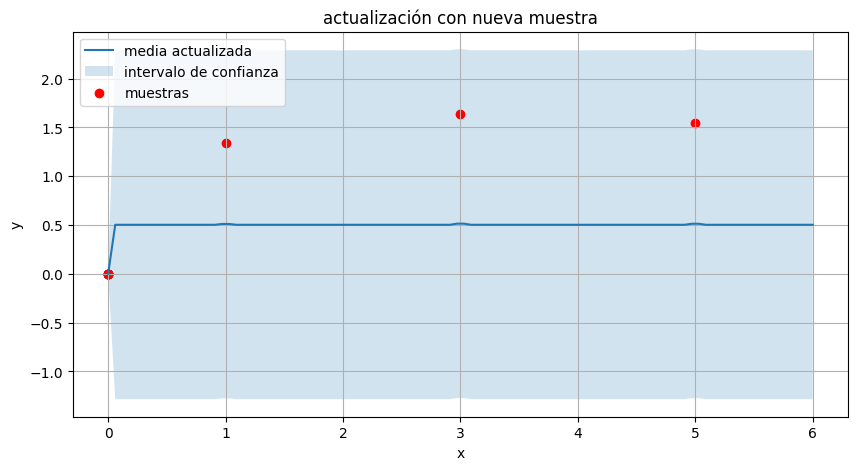

In [12]:
def f(x):
    return np.sin(x) + 0.5*x

x_new = x_uncertainty.reshape(1, -1)

# calculamos el valor real
y_new = f(x_new).ravel()

X_train = np.vstack((X_train, x_new))
y_train = np.append(y_train, y_new)

# reentrenamos el modelo
gp.fit(X_train, y_train)

# volvemos a predecir
y_pred, y_std = gp.predict(X_test, return_std=True)

# graficamos el modelo actualizado
plt.figure(figsize=(10,5))

plt.plot(X_test, y_pred, label="media actualizada")

plt.fill_between(
    X_test.ravel(),
    y_pred - 1.96*y_std,
    y_pred + 1.96*y_std,
    alpha=0.2,
    label="intervalo de confianza"
)

plt.scatter(X_train, y_train, color="red", label="muestras")

plt.title("actualización con nueva muestra")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

Repitamos el proceso 30 veces con una función distinta.

$$ f(x) = \sin{(\frac{x}{3})} + \cos{(2x)},\ \ \ \ x \in [-5\pi, 5\pi] $$

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


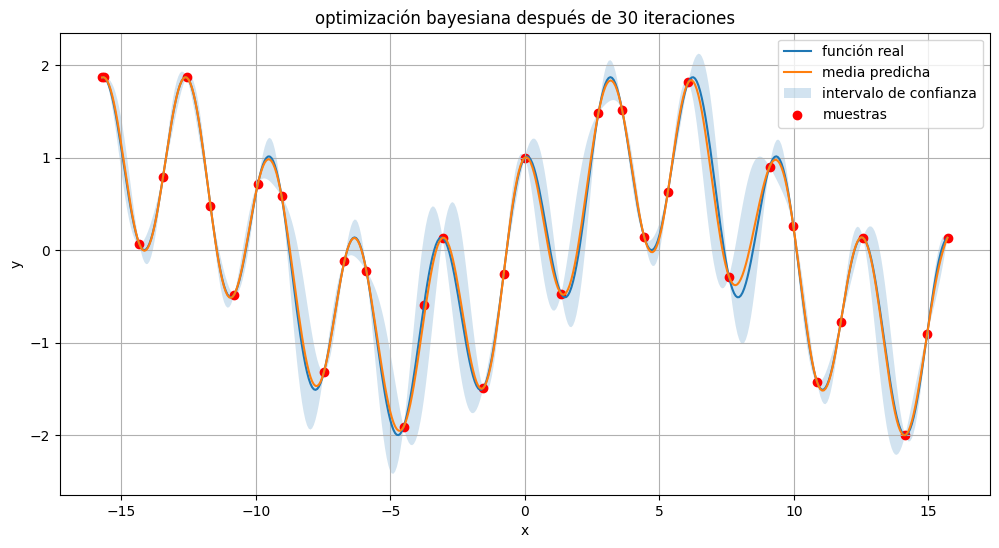

In [13]:
def f(x):
    return np.sin(x/3) + np.cos(2*x)

# dominio
X_test = np.linspace(-5*np.pi, 5*np.pi, 500).reshape(-1, 1)

X_train = np.array([[-4*np.pi], [0], [4*np.pi]])
y_train = f(X_train).ravel()

# kernel
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

# modelo
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=10)

# repetir 30 veces
for i in range(30):
    # entrenar modelo
    gp.fit(X_train, y_train)

    # predecir
    y_pred, y_std = gp.predict(X_test, return_std=True)

    # elegir nuevo punto donde hay mayor incertidumbre
    x_new = X_test[np.argmax(y_std)].reshape(1, -1)
    y_new = f(x_new).ravel()

    # agregar nueva muestra
    X_train = np.vstack((X_train, x_new))
    y_train = np.append(y_train, y_new)

# predicción final
y_pred, y_std = gp.predict(X_test, return_std=True)

# gráfica final
plt.figure(figsize=(12,6))

plt.plot(X_test, f(X_test), label="función real")
plt.plot(X_test, y_pred, label="media predicha")

plt.fill_between(
    X_test.ravel(),
    y_pred - 1.96*y_std,
    y_pred + 1.96*y_std,
    alpha=0.2,
    label="intervalo de confianza"
)

plt.scatter(X_train, y_train, color="red", label="muestras")
plt.title("optimización bayesiana después de 30 iteraciones")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

### Actividad

1. Modificar el comportamiento de selección para elegir el máximo de las predicciones como el siguiente punto.
2. Modificar el comportamiento de selección para elegir el mínimo de las predicciones como el siguiente punto.

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning

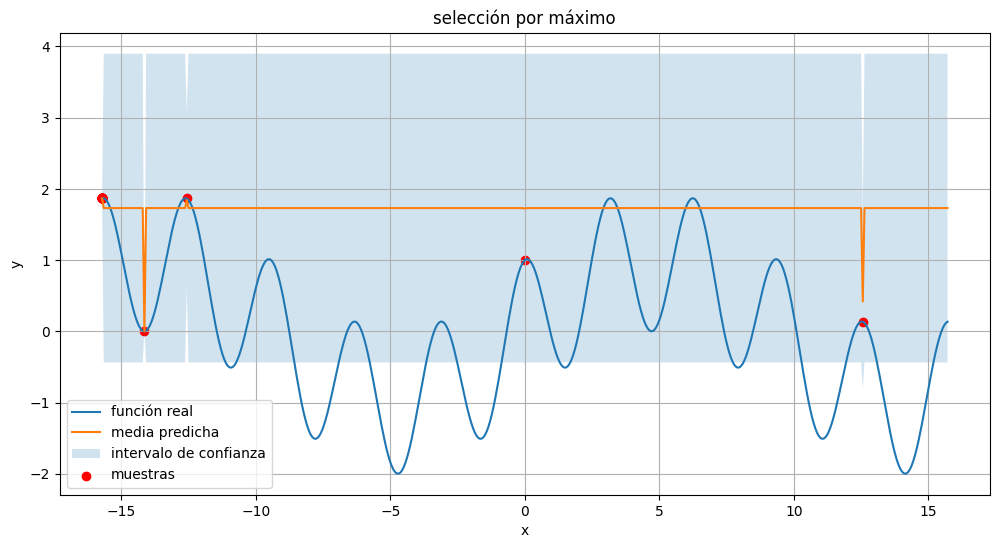

In [14]:
# máximo de las predicciones

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# función
def f(x):
    return np.sin(x/3) + np.cos(2*x)

# dominio
X_test = np.linspace(-5*np.pi, 5*np.pi, 500).reshape(-1, 1)

# muestras iniciales
X_train = np.array([[-4*np.pi], [0], [4*np.pi]])
y_train = f(X_train).ravel()

# kernel y modelo
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=10)

# repetir 30 veces
for i in range(30):
    gp.fit(X_train, y_train)

    y_pred, y_std = gp.predict(X_test, return_std=True)

    # elegir el punto donde la predicción es máxima
    x_new = X_test[np.argmax(y_pred)].reshape(1, -1)
    y_new = f(x_new).ravel()

    X_train = np.vstack((X_train, x_new))
    y_train = np.append(y_train, y_new)

# predicción final
gp.fit(X_train, y_train)
y_pred, y_std = gp.predict(X_test, return_std=True)

# gráfica
plt.figure(figsize=(12,6))
plt.plot(X_test, f(X_test), label="función real")
plt.plot(X_test, y_pred, label="media predicha")
plt.fill_between(
    X_test.ravel(),
    y_pred - 1.96*y_std,
    y_pred + 1.96*y_std,
    alpha=0.2,
    label="intervalo de confianza"
)
plt.scatter(X_train, y_train, color="red", label="muestras")
plt.title("selección por máximo")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning

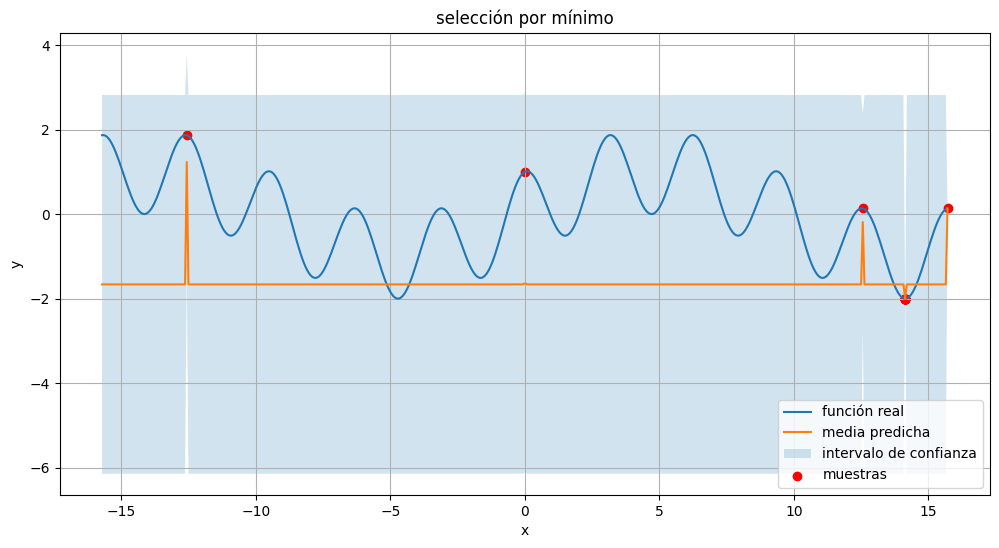

In [15]:
# mínimo de las predicciones

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# función
def f(x):
    return np.sin(x/3) + np.cos(2*x)

# dominio
X_test = np.linspace(-5*np.pi, 5*np.pi, 500).reshape(-1, 1)

# muestras iniciales
X_train = np.array([[-4*np.pi], [0], [4*np.pi]])
y_train = f(X_train).ravel()

# kernel y modelo
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=10)

# repetir 30 veces
for i in range(30):
    gp.fit(X_train, y_train)

    y_pred, y_std = gp.predict(X_test, return_std=True)

    # elegir el punto donde la predicción es mínima
    x_new = X_test[np.argmin(y_pred)].reshape(1, -1)
    y_new = f(x_new).ravel()

    X_train = np.vstack((X_train, x_new))
    y_train = np.append(y_train, y_new)

# predicción final
gp.fit(X_train, y_train)
y_pred, y_std = gp.predict(X_test, return_std=True)

# gráfica
plt.figure(figsize=(12,6))
plt.plot(X_test, f(X_test), label="función real")
plt.plot(X_test, y_pred, label="media predicha")
plt.fill_between(
    X_test.ravel(),
    y_pred - 1.96*y_std,
    y_pred + 1.96*y_std,
    alpha=0.2,
    label="intervalo de confianza"
)
plt.scatter(X_train, y_train, color="red", label="muestras")
plt.title("selección por mínimo")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()